In [1]:

import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model

class ReflectionPadding2D(tf.keras.layers.Layer):
    def __init__(self, padding=(1, 1), **kwargs):
        super(ReflectionPadding2D, self).__init__(**kwargs)
        self.padding = padding

    def call(self, input_tensor):
        padding_width, padding_height = self.padding

        return tf.pad(
            input_tensor,
            [
                [0, 0],
                [padding_height, padding_height],
                [padding_width, padding_width],
                [0, 0],
            ],
            mode="REFLECT",
        )

class InstanceNormalization(tf.keras.layers.Layer):
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name="gamma",
            shape=(input_shape[-1],),
            initializer="ones",
            trainable=True,
        )

        self.beta = self.add_weight(
            name="beta",
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True,
        )

    def call(self, x):
        mean, variance = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        x = (x - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * x + self.beta







generator_g = load_model(
    "../models/generator_g_epoch_220.keras",
    custom_objects={
        "InstanceNormalization": InstanceNormalization(),
        "ReflectionPadding2D": ReflectionPadding2D()
    }
)

generator_f = load_model(
    "../models/generator_f_epoch_220.keras",
    custom_objects={
        "InstanceNormalization": InstanceNormalization(),
        "ReflectionPadding2D": ReflectionPadding2D()
    }
)


def preprocess_image(path, size=128):

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (size, size))
    img = (tf.cast(img, tf.float32) / 127.5) - 1
    img = tf.expand_dims(img, 0)

    return img


def postprocess(img):

    img = (img + 1) * 127.5
    img = tf.clip_by_value(img, 0, 255)

    #img = sharpen(img)

    img = tf.image.resize(img, (256,256), method="lanczos3")
    img = tf.image.adjust_contrast(img, 1.05)
    return tf.cast(img, tf.uint8)


def sharpen(img):
   gaussian = cv2.GaussianBlur(img, (0,0), 1.2)
   sharpened = cv2.addWeighted(img, 1.5, gaussian, -0.5, 0)
   img= sharpened
   return img


def young_to_old(path):

    img = preprocess_image(path)
    
    generated = generator_g(img, training=False)

    return postprocess(generated[0])


def old_to_young(path):

    img = preprocess_image(path)

    generated = generator_f(img, training=False)

    return postprocess(generated[0])

In [19]:
from PIL import Image

path_src = r"C:\Users\Lenovo\Desktop\test_5.jpg"
result = young_to_old(path_src)
Image.fromarray(result.numpy()).save(r"C:\Users\Lenovo\Desktop\test_5_old.jpg")

In [11]:
path_src = r"C:\Users\Lenovo\Desktop\test_6.jpg"
result = old_to_young(path_src)
Image.fromarray(result.numpy()).save(r"C:\Users\Lenovo\Desktop\test_6_young.jpg")

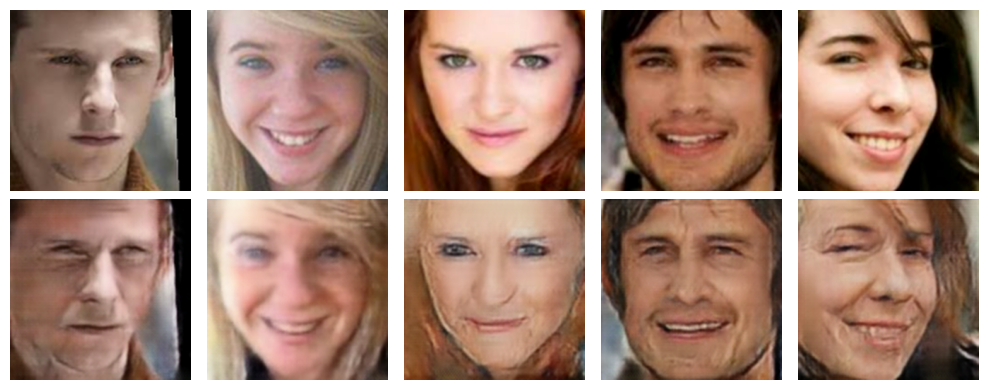

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import random
import cv2

IMG_SIZE = 128   


def generate_examples(image_folder, generator, n=5):

    paths = glob.glob(image_folder + "/*")
    sample_paths = random.sample(paths, n)

    inputs = []
    outputs = []

    for path in sample_paths:

        img = preprocess_image(path)

       # img = tf.expand_dims(img, axis=0)
        generated = generator(img, training=False)

        inp = postprocess(img[0]).numpy()
        out = postprocess(generated[0]).numpy()

        inputs.append(inp)
        outputs.append(out)

    plt.figure(figsize=(10,4))

    for i in range(n):

        plt.subplot(2, n, i+1)
        plt.imshow(inputs[i])
        plt.axis("off")

        plt.subplot(2, n, n+i+1)
        plt.imshow(outputs[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


generate_examples(r"C:\Users\Lenovo\Desktop\young", generator_g)
